In [ ]:
!pip install tensorflow

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Activation

from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import Dropout, BatchNormalization

from sklearn import metrics
from sklearn import preprocessing
from sklearn import model_selection
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score


In [2]:
file = r'/content/drive/MyDrive/Bathymetry/ECHOSOUNDER/bathymetry_processed.csv'
df = pd.read_csv(file).dropna()

# Column
band = ['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']
df = df[(df[band] != 0).any(axis=1)]

print(f"\n{'='*80}")
print(f"DATAFRAME")
print(f"{'='*80}")
df


DATAFRAME


,row_id,lat,lon,depth,wtemp,B1,B2,B3,B4,B8,...,B11,B12,NDVI,NDWI,SAVI,MNDWI,WRI,NDTI,SPMI,BI
0,0,13.923969,120.615534,1.07,31.37,0.111029,0.130971,0.144726,0.122365,0.100401,...,0.080909,0.055143,-0.098599,0.180826,-0.045584,0.282834,1.473122,-0.083720,0.934294,0.132687
1,1,13.924113,120.615481,0.97,31.39,0.107183,0.121676,0.133178,0.108801,0.092195,...,0.071381,0.048398,-0.082617,0.181843,-0.035533,0.302098,1.479303,-0.100739,0.894185,0.121218
2,2,13.924429,120.615473,0.88,31.44,0.107183,0.113093,0.125614,0.106534,0.089975,...,0.070103,0.047771,-0.084267,0.165309,-0.035662,0.283627,1.450216,-0.082187,0.942009,0.115080
3,3,13.924968,120.615568,1.07,31.31,0.100961,0.101782,0.110963,0.093725,0.079290,...,0.067291,0.049496,-0.083432,0.166479,-0.032172,0.245002,1.396420,-0.084217,0.920841,0.102157
4,4,13.925392,120.615680,1.02,31.30,0.105541,0.106148,0.116831,0.100395,0.087969,...,0.077465,0.056869,-0.065965,0.140929,-0.027076,0.202607,1.313063,-0.075667,0.945799,0.107791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50485,12604,6.872635,122.058689,3.70,27.24,0.136691,0.143318,0.167065,0.130245,0.110453,...,0.207599,0.129236,-0.082231,0.203995,-0.040083,-0.108190,0.934784,-0.123842,0.908784,0.146876
50486,12605,6.872634,122.058687,3.70,27.24,0.136691,0.143318,0.167065,0.130245,0.110453,...,0.207599,0.129236,-0.082231,0.203995,-0.040083,-0.108190,0.934784,-0.123842,0.908784,0.146876
50487,12606,6.872630,122.058681,3.70,27.24,0.136691,0.143318,0.167065,0.130245,0.110453,...,0.207599,0.129236,-0.082231,0.203995,-0.040083,-0.108190,0.934784,-0.123842,0.908784,0.146876
50488,12607,6.872623,122.058673,3.70,27.24,0.136691,0.239674,0.287974,0.300445,0.280250,...,0.207599,0.129236,-0.034777,0.013593,-0.028030,0.162185,1.206149,0.021194,1.253557,0.276031


In [3]:
# Input features and target
X = df[['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']].values
y = df['depth'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [4]:
# ---------------------------------------------------------
# 1. Model Architectures
# ---------------------------------------------------------

def create_transformer_model(input_shape=(8,), n_blocks=3, embed_dim=64, n_heads=4, ff_dim=128):
    """
    Transformer-based bathymetry depth predictor.

    Each spectral band is treated as a 'token', allowing the model to learn
    cross-band attention — e.g. how B2 relates to B8 for depth estimation.

    Args:
        input_shape : (n_bands,) — e.g. (8,) for B1,B2,B3,B4,B8,B8A,B11,B12
        n_blocks    : number of Transformer encoder blocks
        embed_dim   : embedding dimension (must be divisible by n_heads)
        n_heads     : number of attention heads
        ff_dim      : feed-forward hidden dimension inside each block
    """
    assert embed_dim % n_heads == 0, "embed_dim must be divisible by n_heads"

    n_bands = input_shape[0]  # 8

    inputs = layers.Input(shape=input_shape)  # (batch, 8)

    # ── 1. Embed each band into embed_dim space ──────────────
    # Reshape to (batch, n_bands, 1) so each band is a separate token
    x = layers.Reshape((n_bands, 1))(inputs)

    # Project each token from dim-1 → embed_dim
    x = layers.Dense(embed_dim)(x)  # (batch, n_bands, embed_dim)

    # ── 2. Learnable positional encoding (one per band) ──────
    positions = tf.range(start=0, limit=n_bands, delta=1)
    pos_embedding = layers.Embedding(input_dim=n_bands, output_dim=embed_dim)(positions)
    x = x + pos_embedding  # (batch, n_bands, embed_dim)

    # ── 3. Transformer Encoder Blocks ────────────────────────
    for i in range(n_blocks):
        # — Multi-Head Self-Attention —
        attn_out = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=embed_dim // n_heads,
            dropout=0.1
        )(x, x)                                     # self-attention
        x = layers.Add()([x, attn_out])             # residual
        x = layers.LayerNormalization(epsilon=1e-6)(x)

        # — Feed-Forward block —
        ff = layers.Dense(ff_dim, activation='relu')(x)
        ff = layers.Dropout(0.1)(ff)
        ff = layers.Dense(embed_dim)(ff)
        x = layers.Add()([x, ff])                   # residual
        x = layers.LayerNormalization(epsilon=1e-6)(x)

    # ── 4. Aggregate band tokens → single vector ─────────────
    # Global average over the band (token) dimension
    x = layers.GlobalAveragePooling1D()(x)  # (batch, embed_dim)

    # ── 5. Regression head ───────────────────────────────────
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    return Model(inputs=inputs, outputs=outputs, name='Transformer_Bathymetry')

In [5]:
# ---------------------------------------------------------
# 3. Improved PINN Wrapper
# ---------------------------------------------------------

class PINNWrapper(Model):
    """
    Physics-Informed Neural Network for bathymetry estimation.
    """

    def __init__(self, base_model, n_bands=8, lambda_phy=0.1,
                 depth_min=0.0, depth_max=30.0, adaptive_lambda=True,
                 init_k=None, init_R0=None, init_Rinf=None, **kwargs):
        super().__init__(**kwargs)

        self.base_model = base_model
        self.n_bands = n_bands
        self.depth_min = depth_min
        self.depth_max = depth_max
        self.adaptive_lambda = adaptive_lambda
        self.lambda_phy_initial = lambda_phy

        # --- Physical Parameter Initialization ---
        if init_k is None:
            init_k = np.array([0.1] * n_bands)
        if init_R0 is None:
            init_R0 = np.array([0.15] * n_bands)
        if init_Rinf is None:
            init_Rinf = np.array([0.05] * n_bands)

        # Store init values for get_config()
        self._init_k    = np.array(init_k,    dtype=np.float32).tolist()
        self._init_R0   = np.array(init_R0,   dtype=np.float32).tolist()
        self._init_Rinf = np.array(init_Rinf, dtype=np.float32).tolist()

        init_k    = np.array(init_k,    dtype=np.float32)
        init_R0   = np.array(init_R0,   dtype=np.float32)
        init_Rinf = np.array(init_Rinf, dtype=np.float32)

        self._raw_k = tf.Variable(
            tf.math.log(np.exp(init_k) + 1e-7) - tf.math.log(1.0 + 1e-7),
            trainable=True, name='raw_k', dtype=tf.float32
        )
        init_Rinf_clipped = np.clip(init_Rinf, 1e-6, 1.0 - 1e-6)
        self._raw_Rinf = tf.Variable(
            tf.math.log(init_Rinf_clipped / (1 - init_Rinf_clipped)),
            trainable=True, name='raw_Rinf', dtype=tf.float32
        )
        init_delta = np.maximum(init_R0 - init_Rinf, 0.01)
        self._raw_delta = tf.Variable(
            tf.math.log(np.exp(init_delta) + 1e-7) - tf.math.log(1.0 + 1e-7),
            trainable=True, name='raw_delta', dtype=tf.float32
        )
        self.lambda_phy = tf.Variable(
            initial_value=lambda_phy, trainable=False, dtype=tf.float32
        )

        # Metrics
        self.loss_fn             = tf.keras.losses.MeanSquaredError()
        self.rmse_metric         = tf.keras.metrics.RootMeanSquaredError(name='rmse')
        self.mae_metric          = tf.keras.metrics.MeanAbsoluteError(name='mae')
        self.data_loss_tracker   = tf.keras.metrics.Mean(name='loss_data')
        self.phy_loss_tracker    = tf.keras.metrics.Mean(name='loss_phy')
        self.total_loss_tracker  = tf.keras.metrics.Mean(name='loss')

    # ── ADD THIS ──────────────────────────────────────────────────────────────
    def get_config(self):
        config = super().get_config()
        config.update({
            # base_model serialised via its own get_config / save format
            "base_model":      tf.keras.layers.serialize(self.base_model),
            "n_bands":         self.n_bands,
            "lambda_phy":      self.lambda_phy_initial,
            "depth_min":       self.depth_min,
            "depth_max":       self.depth_max,
            "adaptive_lambda": self.adaptive_lambda,
            "init_k":          self._init_k,
            "init_R0":         self._init_R0,
            "init_Rinf":       self._init_Rinf,
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Deserialise the nested base_model before passing to __init__
        config["base_model"] = tf.keras.layers.deserialize(config["base_model"])
        return cls(**config)

    @property
    def k(self):
        """Attenuation coefficients (Constrained: k > 0)"""
        return tf.nn.softplus(self._raw_k)

    @property
    def Rinf(self):
        """Deep water reflectance (Constrained: 0 < R < 1)"""
        return tf.nn.sigmoid(self._raw_Rinf)

    @property
    def R0(self):
        """Shallow reflectance (Constrained: R0 > Rinf)"""
        return self.Rinf + tf.nn.softplus(self._raw_delta)

    def compile(self, optimizer, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer

    @property
    def metrics(self):
        return [
            self.total_loss_tracker, self.rmse_metric, self.mae_metric,
            self.data_loss_tracker, self.phy_loss_tracker
        ]

    def apply_depth_constraint(self, depth_pred):
        return tf.clip_by_value(depth_pred, self.depth_min, self.depth_max)

    def beer_lambert_law(self, depth):
        """
        Compute expected reflectance: R(z) = R_inf + (R_0 - R_inf) * exp(-k * z)
        """
        # Ensure shapes are broadcastable: (1, n_bands) and (batch, 1)
        k = tf.reshape(self.k, [1, -1])
        R0 = tf.reshape(self.R0, [1, -1])
        Rinf = tf.reshape(self.Rinf, [1, -1])

        depth_expanded = tf.expand_dims(depth, -1)

        # Added epsilon for numerical stability if k*z becomes large
        attenuation = tf.exp(-k * depth_expanded + 1e-7)

        return Rinf + (R0 - Rinf) * attenuation

    def compute_physics_loss(self, reflectance_obs, depth_pred):
        reflectance_sim = self.beer_lambert_law(depth_pred)

        # Normalized physics loss (MSE relative to signal magnitude)
        loss_phy = self.loss_fn(reflectance_obs, reflectance_sim)
        return loss_phy

    def train_step(self, data):
        (x, reflectance_obs), y_true = data

        with tf.GradientTape() as tape:
            # 1. Predict depth
            y_pred = self.base_model(x, training=True)
            y_pred = self.apply_depth_constraint(y_pred)

            # 2. Data Loss
            loss_data = self.loss_fn(y_true, y_pred)

            # 3. Physics Loss
            loss_phy = self.compute_physics_loss(reflectance_obs, y_pred)

            # 4. Total Weighted Loss
            total_loss = loss_data + self.lambda_phy * loss_phy

        # Compute gradients for both NN weights and Physics parameters
        grads = tape.gradient(total_loss, self.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.data_loss_tracker.update_state(loss_data)
        self.phy_loss_tracker.update_state(loss_phy)
        self.rmse_metric.update_state(y_true, y_pred)
        self.mae_metric.update_state(y_true, y_pred)

        return {
            "loss": self.total_loss_tracker.result(),
            "rmse": self.rmse_metric.result(),
            "mae": self.mae_metric.result(),
            "loss_data": self.data_loss_tracker.result(),
            "loss_phy": self.phy_loss_tracker.result(),
            "lambda": self.lambda_phy,
            "k_mean": tf.reduce_mean(self.k)
        }

    def test_step(self, data):
        (x, reflectance_obs), y_true = data
        y_pred = self.base_model(x, training=False)
        y_pred = self.apply_depth_constraint(y_pred)

        loss_data = self.loss_fn(y_true, y_pred)
        loss_phy = self.compute_physics_loss(reflectance_obs, y_pred)
        total_loss = loss_data + self.lambda_phy * loss_phy

        self.total_loss_tracker.update_state(total_loss)
        self.data_loss_tracker.update_state(loss_data)
        self.phy_loss_tracker.update_state(loss_phy)
        self.rmse_metric.update_state(y_true, y_pred)
        self.mae_metric.update_state(y_true, y_pred)

        return {
            "loss": self.total_loss_tracker.result(),
            "rmse": self.rmse_metric.result(),
            "mae": self.mae_metric.result(),
            "loss_data": self.data_loss_tracker.result(),
            "loss_phy": self.phy_loss_tracker.result()
        }

    def call(self, inputs):
        if isinstance(inputs, tuple):
            x, _ = inputs
        else:
            x = inputs
        return self.base_model(x, training=False)

In [6]:
# ---------------------------------------------------------
# 4. Training Setup Function
# ---------------------------------------------------------

def prepare_improved_pinn_training(X_train, y_train, X_test, y_test,
                                  base_model, n_bands=8, total_epochs=500):
    """
    Prepare data and model for improved PINN training.
    Calculates physical initial guesses and configures training loop.
    """
    print("="*70)
    print("SETTING UP IMPROVED PINN TRAINING")
    print("="*70)

    # --- 1. Smart Initialization Estimation ---
    shallow_thresh = np.percentile(y_train, 10)
    shallow_mask = y_train <= shallow_thresh
    if np.sum(shallow_mask) > 0:
        R0_estimate = np.median(X_train[shallow_mask], axis=0)
    else:
        R0_estimate = np.median(X_train, axis=0) * 1.2

    deep_thresh = np.percentile(y_train, 90)
    deep_mask = y_train >= deep_thresh
    if np.sum(deep_mask) > 0:
        Rinf_estimate = np.median(X_train[deep_mask], axis=0)
    else:
        Rinf_estimate = np.median(X_train, axis=0) * 0.5

    # Ensure float32 for TF compatibility
    R0_estimate = np.array(R0_estimate, dtype=np.float32)
    Rinf_estimate = np.array(Rinf_estimate, dtype=np.float32)

    # Estimate k
    k_estimate = -np.log(0.1) / max(deep_thresh - shallow_thresh, 1.0)
    k_estimate = np.full(n_bands, k_estimate, dtype=np.float32)

    print(f"\nPhysical Parameter Initialization:")
    print(f"  R0 (Shallow):  {np.round(R0_estimate, 3)}")
    print(f"  Rinf (Deep):   {np.round(Rinf_estimate, 3)}")
    print(f"  Init k (avg):  {np.mean(k_estimate):.4f}")

    # --- 2. Dataset Pipeline ---
    batch_size = 64

    train_dataset = tf.data.Dataset.from_tensor_slices(
        ((X_train, X_train), y_train)
    ).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    test_dataset = tf.data.Dataset.from_tensor_slices(
        ((X_test, X_test), y_test)
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # --- 3. Model Instantiation ---
    pinn_model = PINNWrapper(
        base_model=base_model,
        n_bands=n_bands,
        lambda_phy=1.0,
        depth_min=0.0,
        depth_max=y_train.max() * 1.2,
        adaptive_lambda=True,
        init_k=k_estimate,
        init_R0=R0_estimate,
        init_Rinf=Rinf_estimate
    )

    # --- 4. Compilation ---
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-5
    )
    pinn_model.compile(optimizer=optimizer)

    # --- 5. Callbacks (FIXED: Added mode='min') ---
    callbacks = [
        LambdaSchedulerCallback(pinn_model, total_epochs=total_epochs),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=20,
            min_lr=1e-6,
            verbose=1,
            mode='min'  # Explicit mode
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor='val_rmse',
            patience=50,
            restore_best_weights=True,
            verbose=1,
            mode='min'  # Explicit mode
        ),

        tf.keras.callbacks.ModelCheckpoint(
            'best_pinn_model.keras',
            monitor='val_rmse',
            save_best_only=True,
            verbose=1,
            mode='min'  # Explicit mode
        )
    ]

    print(f"\nTraining Configuration:")
    print(f"  Batch size: {batch_size}")
    print(f"  Physics Weight Scheduling: Active (1.0 -> 0.1)")
    print("="*70)

    return pinn_model, train_dataset, test_dataset, callbacks

In [7]:
# ---------------------------------------------------------
# 2. Callbacks
# ---------------------------------------------------------

class LambdaSchedulerCallback(tf.keras.callbacks.Callback):
    """
    Adjusts the physics weight (lambda) during training.
    Starts high to enforce physics, decays to let data refine the fit.
    """
    def __init__(self, pinn_model, total_epochs, decay_type='cosine'):
        super().__init__()
        self.pinn_model = pinn_model
        self.total_epochs = total_epochs
        self.decay_type = decay_type

    def on_epoch_begin(self, epoch, logs=None):
        if not self.pinn_model.adaptive_lambda:
            return

        progress = epoch / self.total_epochs

        if self.decay_type == 'cosine':
            # Smooth decay from initial to 10% of initial
            new_lambda = self.pinn_model.lambda_phy_initial * (0.1 + 0.9 * (1 + np.cos(progress * np.pi)) / 2)
        elif self.decay_type == 'linear':
            new_lambda = self.pinn_model.lambda_phy_initial * (1.0 - 0.9 * progress)
        else:
            new_lambda = self.pinn_model.lambda_phy_initial

        self.pinn_model.lambda_phy.assign(new_lambda)

class PhysicsMonitorCallback(tf.keras.callbacks.Callback):
    """Monitor learned physics parameters during training"""

    def __init__(self, monitor_freq=50):
        super().__init__()
        self.monitor_freq = monitor_freq

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.monitor_freq == 0:
            # Access the wrapper properties
            try:
                k = self.model.k.numpy()
                R0 = self.model.R0.numpy()
                Rinf = self.model.Rinf.numpy()

                print(f"\n{'='*40}")
                print(f"[Physics Parameters @ Epoch {epoch}]")
                print(f"  k  (attenuation): {np.round(k, 4)}")
                print(f"  R0 (shallow):    {np.round(R0, 4)}")
                print(f"  Rinf (deep):     {np.round(Rinf, 4)}")
                print(f"{'='*40}")
            except AttributeError:
                print("Warning: Model does not have physics parameters (k, R0, Rinf).")

In [8]:
# -------------------------------------------------------------------------
# 2. Visualization
# -------------------------------------------------------------------------

def plot_training_history(history, save_dir):
    """Plot comprehensive training history with safety checks"""

    required_keys = ['loss', 'rmse', 'mae', 'loss_data', 'loss_phy']
    if not all(k in history.history for k in required_keys):
        print("Warning: History object is missing some keys. Skipping detailed plots.")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Styles
    train_style = {'label': 'Train', 'color': 'blue', 'linewidth': 2}
    val_style = {'label': 'Val', 'color': 'orange', 'linestyle': '--', 'linewidth': 2}

    # 1. Total Loss
    ax = axes[0, 0]
    ax.plot(history.history.get('loss', []), **train_style)
    ax.plot(history.history.get('val_loss', []), **val_style)
    ax.set_title('Total Weighted Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')  # Log scale often helps see loss convergence

    # 2. RMSE
    ax = axes[0, 1]
    ax.plot(history.history.get('rmse', []), **train_style)
    ax.plot(history.history.get('val_rmse', []), **val_style)
    ax.set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Meters')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. MAE
    ax = axes[0, 2]
    ax.plot(history.history.get('mae', []), **train_style)
    ax.plot(history.history.get('val_mae', []), **val_style)
    ax.set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Meters')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Data Loss
    ax = axes[1, 0]
    ax.plot(history.history.get('loss_data', []), **train_style)
    ax.plot(history.history.get('val_loss_data', []), **val_style)
    ax.set_title('Data Fidelity Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 5. Physics Loss
    ax = axes[1, 1]
    ax.plot(history.history.get('loss_phy', []), **train_style)
    ax.plot(history.history.get('val_loss_phy', []), **val_style)
    ax.set_title('Physics Consistency Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 6. Lambda Schedule
    ax = axes[1, 2]
    if 'lambda' in history.history:
        ax.plot(history.history['lambda'], color='green', linewidth=2)
        ax.set_title('Physics Weight (λ) Decay', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Lambda')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No Lambda Schedule Data', ha='center', va='center')

    plt.tight_layout()

    # Save
    save_path = os.path.join(save_dir, 'pinn_training_history.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved training history plot to: {save_path}")

In [9]:
# -------------------------------------------------------------------------
# 3. Evaluation
# -------------------------------------------------------------------------

def evaluate_pinn(pinn_model, X_test, y_test, save_dir):
    """Comprehensive evaluation of PINN model including residual analysis"""

    print("\n" + "="*70)
    print("PINN MODEL EVALUATION")
    print("="*70)

    # 1. Predictions
    y_pred = pinn_model.predict((X_test, X_test), verbose=0).flatten()

    # 2. Metrics
    mse = np.mean((y_test - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))
    bias = np.mean(y_pred - y_test) # Mean Error (Bias)
    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - y_test.mean())**2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"\nPerformance Metrics:")
    print(f"  RMSE:  {rmse:.3f} m")
    print(f"  MAE:   {mae:.3f} m")
    print(f"  Bias:  {bias:.3f} m (Positive = Overestimation)")
    print(f"  R²:    {r2:.4f}")

    # 3. Learned Physics Parameters
    try:
        print(f"\nLearned Physics Parameters:")
        print(f"  k (attenuation):  {np.round(pinn_model.k.numpy(), 4)}")
        print(f"  R0 (shallow):     {np.round(pinn_model.R0.numpy(), 4)}")
        print(f"  Rinf (deep):      {np.round(pinn_model.Rinf.numpy(), 4)}")
    except AttributeError:
        print("Could not retrieve physics parameters.")

    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scatter Plot: True vs Pred
    ax = axes[0]
    ax.scatter(y_test, y_pred, alpha=0.5, s=15, edgecolors='k', linewidth=0.2)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='1:1 Line')
    ax.set_xlabel('True Depth (m)', fontsize=12)
    ax.set_ylabel('Predicted Depth (m)', fontsize=12)
    ax.set_title(f'Predicted vs True (R²: {r2:.3f})', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')

    # Residual Plot: Error vs Depth
    ax = axes[1]
    residuals = y_pred - y_test
    ax.scatter(y_test, residuals, alpha=0.5, s=15, c='red', edgecolors='k', linewidth=0.2)
    ax.axhline(y=0, color='k', linestyle='--', lw=2)
    ax.set_xlabel('True Depth (m)', fontsize=12)
    ax.set_ylabel('Residual (Pred - True) [m]', fontsize=12)
    ax.set_title('Residual Distribution', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Add bias annotation
    ax.text(0.05, 0.95, f'Bias: {bias:.3f}m', transform=ax.transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'pinn_predictions_evaluation.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved evaluation plot to: {save_path}")
    print("="*70)

    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'bias': bias}

In [10]:
# -------------------------------------------------------------------------
# 4. Synthetic Data Generator (For Demonstration)
# -------------------------------------------------------------------------

def generate_synthetic_data(n_samples=1000, n_bands=8):
    """Generates synthetic bathymetry data for testing the workflow"""
    print("⚠️ Generating synthetic data for demonstration...")

    # Random depths between 0 and 20m
    depths = np.random.uniform(0, 20, (n_samples, 1))

    # Simulate Reflectance using Beer-Lambert (Inverse Problem)
    # R(z) = R_inf + (R_0 - R_inf) * exp(-k * z)
    R0_true = np.random.uniform(0.1, 0.3, (1, n_bands))
    Rinf_true = np.random.uniform(0.01, 0.05, (1, n_bands))
    k_true = np.random.uniform(0.05, 0.2, (1, n_bands))

    reflectance = Rinf_true + (R0_true - Rinf_true) * np.exp(-k_true * depths)

    # Add noise
    reflectance += np.random.normal(0, 0.01, reflectance.shape)

    # Split
    split = int(0.8 * n_samples)
    return reflectance[:split], depths[:split], reflectance[split:], depths[split:]

COMPLETE PINN BATHYMETRY WORKFLOW

Data Loaded: 37867 train, 12623 test samples.

1. Creating base model...

2. Setting up PINN wrapper...
SETTING UP IMPROVED PINN TRAINING

Physical Parameter Initialization:
  R0 (Shallow):  [0.101 0.114 0.133 0.112 0.09  0.091 0.051 0.035]
  Rinf (Deep):   [0.114 0.119 0.118 0.102 0.099 0.106 0.087 0.065]
  Init k (avg):  0.4718

Training Configuration:
  Batch size: 64
  Physics Weight Scheduling: Active (1.0 -> 0.1)

3. Starting PINN training...
Epoch 1/500
592/592 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - k_mean: 0.9566 - lambda: 1.0000 - loss: 8.9023 - loss_data: 8.8923 - loss_phy: 0.0101 - mae: 1.6807 - rmse: 2.9723
Epoch 1: val_rmse improved from None to 2.58606, saving model to best_pinn_model.keras

Epoch 1: finished saving model to best_pinn_model.keras

[Physics Parameters @ Epoch 0]
  k  (attenuation): [0.9566 0.9566 0.9566 0.9566 0.9566 0.9566 0.9566 0.9566]
  R0 (shallow):    [0.812  0.8168 0.8188 0.8001 0.7968 0.804  0.7856 0.7633]
  Rinf (de

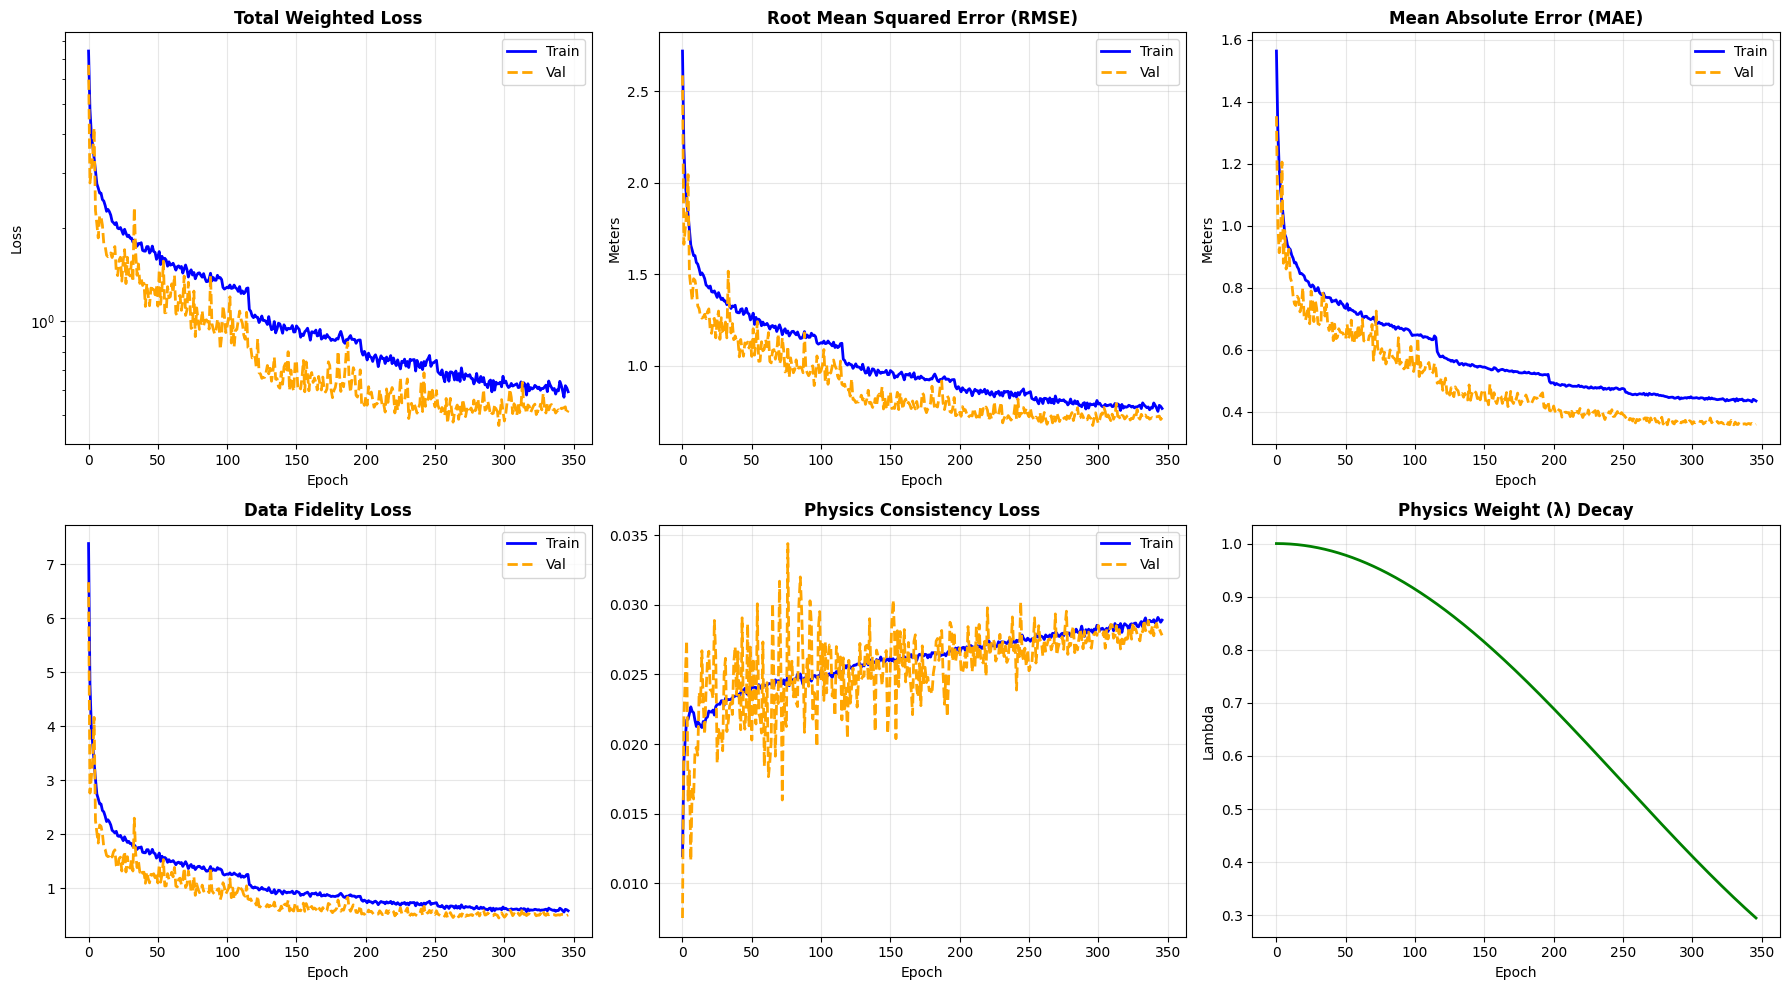

✅ Saved training history plot to: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/pinn_training_history.png

5. Final evaluation...

PINN MODEL EVALUATION

Performance Metrics:
  RMSE:  0.673 m
  MAE:   0.359 m
  Bias:  0.037 m (Positive = Overestimation)
  R²:    0.9504

Learned Physics Parameters:
  k (attenuation):  [0.9566 0.9566 0.9566 0.9566 0.9566 0.9566 0.9566 0.9566]
  R0 (shallow):     [0.812  0.8168 0.8188 0.8001 0.7968 0.804  0.7856 0.7633]
  Rinf (deep):      [0.1139 0.1187 0.1179 0.1018 0.0987 0.1058 0.0874 0.0651]


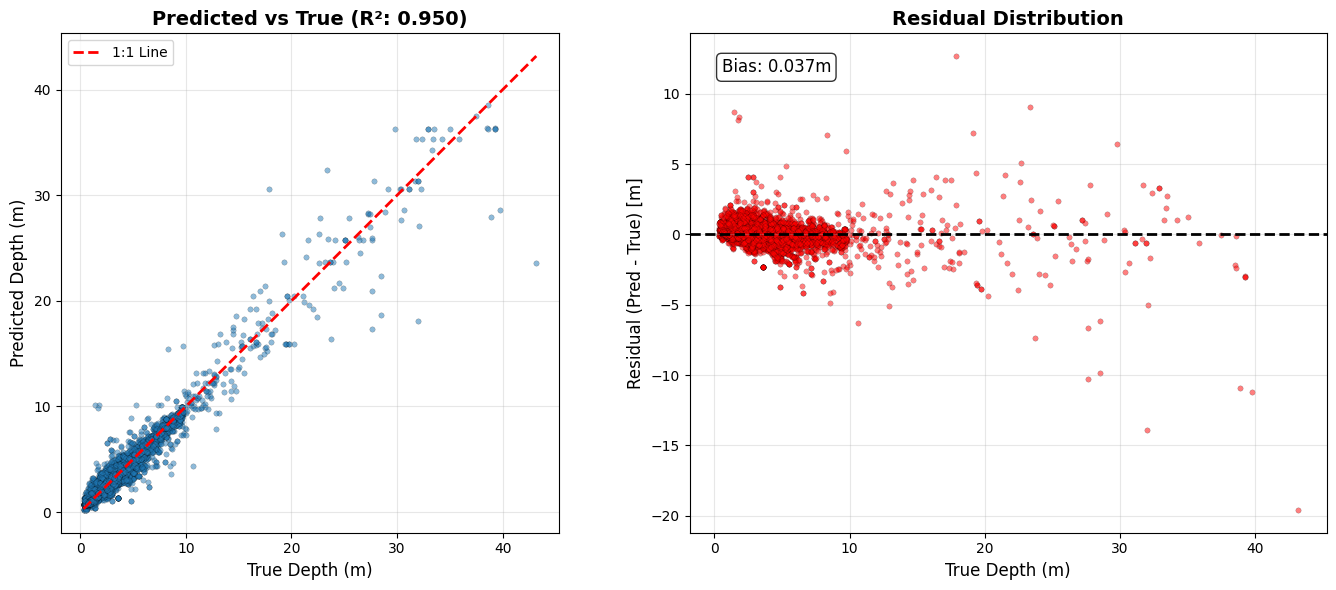

✅ Saved evaluation plot to: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/pinn_predictions_evaluation.png

6. Saving model and parameters...
   ✓ Base model saved: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/base_model.keras
   ✓ Physics params saved: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/physics_params.json
     k=0.956643, R0=0.812017, Rinf=0.113857
   ✓ Full PINN weights saved: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/pinn_weights.weights.h5
   ✓ Metrics saved: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/metrics.json
   ✓ History saved: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/training_history.csv

7. Verifying save integrity...
SETTING UP IMPROVED PINN TRAINING

Physical Parameter Initialization:
  R0 (Shallow):  [0.101 0.114 0.133 0.112 0.09  0.091 0.051 0.035]
  Rinf (Deep):   [0.114 0.119 0.118 0.102 0.099 0.106 0.087 0.065]
  Init k (avg)

In [14]:
# -------------------------------------------------------------------------
# 5. Main Execution
# -------------------------------------------------------------------------

if __name__ == "__main__":

    SAVE_DIR = '/content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4'
    os.makedirs(SAVE_DIR, exist_ok=True)

    print("="*70)
    print("COMPLETE PINN BATHYMETRY WORKFLOW")
    print("="*70)

    # Step 1: Prepare Data
    if 'X_train' not in locals() or 'X_test' not in locals():
        X_train, y_train, X_test, y_test = generate_synthetic_data(n_samples=2000)

    n_bands = X_train.shape[1]
    print(f"\nData Loaded: {X_train.shape[0]} train, {X_test.shape[0]} test samples.")

    # Step 2: Create Base Model
    print("\n1. Creating base model...")
    resnet_model = create_transformer_model(
        input_shape=(n_bands,), n_blocks=3, embed_dim=64, n_heads=4
    )

    # Step 3: Setup PINN
    print("\n2. Setting up PINN wrapper...")
    pinn_model, train_ds, test_ds, callbacks = prepare_improved_pinn_training(
        X_train, y_train, X_test, y_test,
        base_model=resnet_model,
        n_bands=n_bands,
        total_epochs=500
    )
    callbacks.append(PhysicsMonitorCallback(monitor_freq=20))

    # Step 4: Train
    print("\n3. Starting PINN training...")
    history = pinn_model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=500,
        callbacks=callbacks,
        verbose=1
    )

    # Step 5: Visualize
    print("\n4. Generating training plots...")
    plot_training_history(history, save_dir=SAVE_DIR)

    # Step 6: Evaluate
    print("\n5. Final evaluation...")
    metrics = evaluate_pinn(pinn_model, X_test, y_test, save_dir=SAVE_DIR)

    # -------------------------------------------------------------------------
    # Step 7: Save ALL artifacts — base model + physics params together
    # -------------------------------------------------------------------------
    print("\n6. Saving model and parameters...")

    # 7a. Save the base transformer model (weights + architecture)
    base_model_path = os.path.join(SAVE_DIR, 'base_model.keras')
    pinn_model.base_model.save(base_model_path)
    print(f"   ✓ Base model saved: {base_model_path}")

    # 7b. Save physics parameters as JSON (human-readable, easy to reload)
    #     np.save with a dict requires allow_pickle=True on load — error-prone.
    #     JSON is safer and inspectable.
    physics_params = {
        'k':    float(pinn_model.k.numpy().flat[0]),
        'R0':   float(pinn_model.R0.numpy().flat[0]),
        'Rinf': float(pinn_model.Rinf.numpy().flat[0]),
    }

    #physics_params = {
    #    'k': pinn_model.k.numpy(),
    #    'R0': pinn_model.R0.numpy(),
    #    'Rinf': pinn_model.Rinf.numpy(),
    #    'metrics': metrics
    #}

    params_path = os.path.join(SAVE_DIR, 'physics_params.json')
    with open(params_path, 'w') as f:
        json.dump(physics_params, f, indent=2)
    print(f"   ✓ Physics params saved: {params_path}")
    print(f"     k={physics_params['k']:.6f}, "
          f"R0={physics_params['R0']:.6f}, "
          f"Rinf={physics_params['Rinf']:.6f}")

    # 7c. Save full PINN weights (covers k, R0, Rinf AND base model together)
    #     This is the most complete save — use this to resume training or inference.
    pinn_weights_path = os.path.join(SAVE_DIR, 'pinn_weights.weights.h5')
    pinn_model.save_weights(pinn_weights_path)
    print(f"   ✓ Full PINN weights saved: {pinn_weights_path}")

    # 7d. Save metrics + history
    metrics_path = os.path.join(SAVE_DIR, 'metrics.json')
    with open(metrics_path, 'w') as f:
        json.dump({k: float(v) for k, v in metrics.items()}, f, indent=2)
    print(f"   ✓ Metrics saved: {metrics_path}")

    history_path = os.path.join(SAVE_DIR, 'training_history.csv')
    pd.DataFrame(history.history).to_csv(history_path, index=False)
    print(f"   ✓ History saved: {history_path}")

    # -------------------------------------------------------------------------
    # Step 8: Verify the save by reloading and comparing predictions
    # -------------------------------------------------------------------------
    print("\n7. Verifying save integrity...")

    # Reload base model
    reloaded_base = tf.keras.models.load_model(base_model_path)

    # Rebuild PINN wrapper with reloaded base
    pinn_reloaded, _, _, _ = prepare_improved_pinn_training(
        X_train, y_train, X_test, y_test,
        base_model=reloaded_base,
        n_bands=n_bands,
        total_epochs=500
    )

    # Restore full PINN weights (restores k, R0, Rinf exactly)
    # pinn_reloaded.load_weights(pinn_weights_path)
    pinn_reloaded(X_test[:1], training=False)   # ← force build
    pinn_reloaded.load_weights(pinn_weights_path)

    # Compare a sample prediction — should be near-zero difference
    sample = X_test[:10]
    pred_original = pinn_model(sample, training=False).numpy()
    pred_reloaded = pinn_reloaded(sample, training=False).numpy()
    max_diff = np.max(np.abs(pred_original - pred_reloaded))

    if max_diff < 1e-5:
        print(f"   ✓ Save verified — max prediction diff: {max_diff:.2e} (PASS)")
    else:
        print(f"   ✗ WARNING — max prediction diff: {max_diff:.2e} (FAIL, check save)")

    # -------------------------------------------------------------------------
    # Final Summary
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print("✅ WORKFLOW COMPLETE!")
    print("="*70)
    print(f"  Final Test RMSE : {metrics['rmse']:.3f} m")
    print(f"  Final Test R²   : {metrics['r2']:.4f}")
    print(f"\n  Saved files:")
    print(f"    base_model.keras          ← transformer architecture + weights")
    print(f"    pinn_weights.weights.h5   ← FULL save (base + k, R0, Rinf)")
    print(f"    physics_params.json       ← k, R0, Rinf as plain text")
    print(f"    metrics.json              ← evaluation results")
    print(f"    training_history.csv      ← loss curves")
    print(f"\n  Directory: {os.path.abspath(SAVE_DIR)}")
    print("="*70)

In [ ]:
# @title
from IPython.display import HTML

html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>PINN Training Explained</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 20px;
            line-height: 1.6;
        }

        .container {
            max-width: 1200px;
            margin: 0 auto;
            background: white;
            border-radius: 20px;
            box-shadow: 0 20px 60px rgba(0,0,0,0.3);
            overflow: hidden;
        }

        .header {
            background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }

        .header h1 {
            font-size: 2.5em;
            margin-bottom: 10px;
        }

        .header p {
            font-size: 1.2em;
            opacity: 0.9;
        }

        .content {
            padding: 40px;
        }

        .section {
            margin-bottom: 40px;
            padding: 30px;
            background: #f8f9fa;
            border-radius: 15px;
            border-left: 5px solid #667eea;
        }

        .section h2 {
            color: #1e3c72;
            margin-bottom: 20px;
            font-size: 1.8em;
            display: flex;
            align-items: center;
            gap: 10px;
        }

        .section h3 {
            color: #2a5298;
            margin: 20px 0 10px 0;
            font-size: 1.3em;
        }

        .icon {
            font-size: 1.5em;
        }

        .code-block {
            background: #2d2d2d;
            color: #f8f8f2;
            padding: 20px;
            border-radius: 10px;
            overflow-x: auto;
            margin: 15px 0;
            font-family: 'Courier New', monospace;
            font-size: 0.9em;
        }

        .highlight {
            background: #fff3cd;
            padding: 2px 6px;
            border-radius: 3px;
            font-weight: bold;
        }

        .flow-diagram {
            display: flex;
            flex-wrap: wrap;
            gap: 15px;
            margin: 20px 0;
            justify-content: center;
        }

        .flow-step {
            background: white;
            border: 3px solid #667eea;
            border-radius: 10px;
            padding: 20px;
            flex: 1;
            min-width: 200px;
            text-align: center;
            position: relative;
            transition: transform 0.3s ease;
        }

        .flow-step:hover {
            transform: translateY(-5px);
            box-shadow: 0 10px 25px rgba(0,0,0,0.15);
        }

        .flow-step::after {
            content: '→';
            position: absolute;
            right: -25px;
            top: 50%;
            transform: translateY(-50%);
            font-size: 2em;
            color: #667eea;
        }

        .flow-step:last-child::after {
            content: '';
        }

        .flow-step h4 {
            color: #667eea;
            margin-bottom: 10px;
            font-size: 1.1em;
        }

        .equation {
            background: white;
            padding: 20px;
            border-radius: 10px;
            margin: 15px 0;
            text-align: center;
            font-size: 1.2em;
            border: 2px solid #e0e0e0;
        }

        .equation-label {
            color: #666;
            font-size: 0.9em;
            margin-top: 10px;
        }

        .comparison-table {
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            background: white;
            border-radius: 10px;
            overflow: hidden;
        }

        .comparison-table th {
            background: #667eea;
            color: white;
            padding: 15px;
            text-align: left;
        }

        .comparison-table td {
            padding: 15px;
            border-bottom: 1px solid #e0e0e0;
        }

        .comparison-table tr:hover {
            background: #f8f9fa;
        }

        .metric-box {
            display: inline-block;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 15px 25px;
            border-radius: 10px;
            margin: 10px;
            text-align: center;
            min-width: 150px;
        }

        .metric-box .value {
            font-size: 2em;
            font-weight: bold;
        }

        .metric-box .label {
            font-size: 0.9em;
            opacity: 0.9;
        }

        .timeline {
            position: relative;
            padding-left: 40px;
            margin: 20px 0;
        }

        .timeline::before {
            content: '';
            position: absolute;
            left: 15px;
            top: 0;
            bottom: 0;
            width: 3px;
            background: #667eea;
        }

        .timeline-item {
            position: relative;
            margin-bottom: 30px;
            padding: 20px;
            background: white;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }

        .timeline-item::before {
            content: '';
            position: absolute;
            left: -32px;
            top: 25px;
            width: 15px;
            height: 15px;
            border-radius: 50%;
            background: #667eea;
            border: 3px solid white;
        }

        .timeline-item h4 {
            color: #667eea;
            margin-bottom: 10px;
        }

        .alert {
            padding: 15px 20px;
            border-radius: 10px;
            margin: 15px 0;
            display: flex;
            align-items: center;
            gap: 15px;
        }

        .alert-info {
            background: #d1ecf1;
            border-left: 5px solid #0c5460;
            color: #0c5460;
        }

        .alert-success {
            background: #d4edda;
            border-left: 5px solid #155724;
            color: #155724;
        }

        .alert-warning {
            background: #fff3cd;
            border-left: 5px solid #856404;
            color: #856404;
        }

        .tabs {
            display: flex;
            gap: 10px;
            margin-bottom: 20px;
            border-bottom: 2px solid #e0e0e0;
        }

        .tab {
            padding: 10px 20px;
            cursor: pointer;
            border: none;
            background: none;
            font-size: 1em;
            color: #666;
            transition: all 0.3s ease;
        }

        .tab:hover {
            color: #667eea;
        }

        .tab.active {
            color: #667eea;
            border-bottom: 3px solid #667eea;
            font-weight: bold;
        }

        .tab-content {
            display: none;
            animation: fadeIn 0.5s;
        }

        .tab-content.active {
            display: block;
        }

        @keyframes fadeIn {
            from { opacity: 0; transform: translateY(10px); }
            to { opacity: 1; transform: translateY(0); }
        }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🌊 Physics-Informed Neural Network (PINN)</h1>
            <p>Complete Training Explanation for Bathymetry Estimation</p>
        </div>

        <div class="content">
            <!-- Section 1: Overview -->
            <div class="section">
                <h2><span class="icon">🎯</span> What is This Model?</h2>
                <p>A <strong>Physics-Informed Neural Network (PINN)</strong> combines:</p>
                <div class="flow-diagram">
                    <div class="flow-step">
                        <h4>🤖 Neural Network</h4>
                        <p>Learns patterns from data</p>
                        <small>Sentinel-2 reflectance → depth</small>
                    </div>
                    <div class="flow-step">
                        <h4>⚛️ Physics Laws</h4>
                        <p>Beer-Lambert Law</p>
                        <small>Light attenuation in water</small>
                    </div>
                    <div class="flow-step">
                        <h4>📊 Best of Both</h4>
                        <p>Accurate + Realistic</p>
                        <small>Better predictions</small>
                    </div>
                </div>

                <div class="alert alert-info">
                    <span style="font-size: 2em;">💡</span>
                    <div>
                        <strong>Key Insight:</strong> Traditional models only learn from data. PINN also learns from physics, making predictions more accurate and physically realistic.
                    </div>
                </div>
            </div>

            <!-- Section 2: The Architecture -->
            <div class="section">
                <h2><span class="icon">🏗️</span> Model Architecture</h2>

                <div class="tabs">
                    <button class="tab active" onclick="showTab('arch1')">ResNet Base</button>
                    <button class="tab" onclick="showTab('arch2')">PINN Wrapper</button>
                    <button class="tab" onclick="showTab('arch3')">Complete Flow</button>
                </div>

                <div id="arch1" class="tab-content active">
                    <h3>1. Base Model: ResNet</h3>
                    <div class="code-block">
Input: 8 Sentinel-2 bands [B1, B2, B3, B4, B8, B8A, B11, B12]
    ↓
Dense(64) + BatchNorm + ReLU
    ↓
[Residual Block 1] 64 filters
    Dense → BatchNorm → Dropout → Dense → Add(residual) → ReLU
    ↓
[Residual Block 2] 128 filters
    Dense → BatchNorm → Dropout → Dense → Add(residual) → ReLU
    ↓
[Residual Block 3] 256 filters
    Dense → BatchNorm → Dropout → Dense → Add(residual) → ReLU
    ↓
Dense(64) + Dropout(0.3)
    ↓
Output: Predicted Depth (1 value)
                    </div>
                    <p><strong>Why ResNet?</strong> Residual connections help gradient flow, enabling deeper networks and better learning.</p>
                </div>

                <div id="arch2" class="tab-content">
                    <h3>2. PINN Wrapper</h3>
                    <p>Wraps the base model and adds physics constraints:</p>
                    <div class="code-block">
class ImprovedPINNWrapper:
    base_model       # ResNet that predicts depth
    k                # Attenuation coefficient (learnable!)
    R0               # Shallow water reflectance (learnable!)
    Rinf             # Deep water reflectance (learnable!)
    lambda_phy       # Physics loss weight (adaptive!)
                    </div>
                    <p><strong>Key Feature:</strong> Physics parameters (k, R0, Rinf) are <span class="highlight">learned</span> during training, not fixed!</p>
                </div>

                <div id="arch3" class="tab-content">
                    <h3>3. Complete Forward Pass</h3>
                    <div class="timeline">
                        <div class="timeline-item">
                            <h4>Input Data</h4>
                            <p>• Reflectance: 8 bands from Sentinel-2</p>
                            <p>• True depth: Ground truth measurements</p>
                        </div>
                        <div class="timeline-item">
                            <h4>Base Model Prediction</h4>
                            <p>ResNet processes reflectance → predicts depth</p>
                            <div class="code-block">depth_pred = base_model(reflectance)</div>
                        </div>
                        <div class="timeline-item">
                            <h4>Physics Simulation</h4>
                            <p>Use predicted depth to simulate what reflectance <em>should</em> be:</p>
                            <div class="equation">
                                R<sub>sim</sub> = R<sub>∞</sub> + (R<sub>0</sub> - R<sub>∞</sub>) × e<sup>-k × depth</sup>
                                <div class="equation-label">Beer-Lambert Law</div>
                            </div>
                        </div>
                        <div class="timeline-item">
                            <h4>Loss Calculation</h4>
                            <p>Combine data loss and physics loss:</p>
                            <div class="code-block">
loss_data = MSE(depth_true, depth_pred)
loss_physics = MSE(reflectance_observed, reflectance_simulated)
total_loss = loss_data + λ × loss_physics
                            </div>
                        </div>
                        <div class="timeline-item">
                            <h4>Backpropagation</h4>
                            <p>Update all parameters: network weights, k, R0, Rinf</p>
                        </div>
                    </div>
                </div>
            </div>

            <!-- Section 3: The Physics -->
            <div class="section">
                <h2><span class="icon">⚛️</span> The Physics: Beer-Lambert Law</h2>
                <p>Light traveling through water gets absorbed exponentially with depth:</p>

                <div class="equation">
                    R(z) = R<sub>∞</sub> + (R<sub>0</sub> - R<sub>∞</sub>) × e<sup>-k × z</sup>
                </div>

                <h3>Variables Explained:</h3>
                <table class="comparison-table">
                    <tr>
                        <th>Symbol</th>
                        <th>Name</th>
                        <th>Meaning</th>
                        <th>Typical Value</th>
                    </tr>
                    <tr>
                        <td><strong>R(z)</strong></td>
                        <td>Reflectance at depth z</td>
                        <td>How much light returns from depth z</td>
                        <td>0.05 - 0.15</td>
                    </tr>
                    <tr>
                        <td><strong>R<sub>0</sub></strong></td>
                        <td>Shallow reflectance</td>
                        <td>Reflectance at surface (z=0)</td>
                        <td>~0.15 (bright)</td>
                    </tr>
                    <tr>
                        <td><strong>R<sub>∞</sub></strong></td>
                        <td>Deep reflectance</td>
                        <td>Reflectance in very deep water</td>
                        <td>~0.05 (dark)</td>
                    </tr>
                    <tr>
                        <td><strong>k</strong></td>
                        <td>Attenuation coefficient</td>
                        <td>How fast light decreases</td>
                        <td>0.05 - 0.25 m<sup>-1</sup></td>
                    </tr>
                    <tr>
                        <td><strong>z</strong></td>
                        <td>Depth</td>
                        <td>Water depth</td>
                        <td>0 - 30 m</td>
                    </tr>
                </table>

                <div class="alert alert-success">
                    <span style="font-size: 2em;">✨</span>
                    <div>
                        <strong>Innovation:</strong> Unlike traditional methods that use fixed k, R0, Rinf values from literature, our PINN <em>learns</em> these parameters from your specific data and location!
                    </div>
                </div>
            </div>

            <!-- Section 4: Training Process -->
            <div class="section">
                <h2><span class="icon">🎓</span> Training Process Step-by-Step</h2>

                <h3>Epoch 1-100: Early Training</h3>
                <div class="metric-box">
                    <div class="value">λ = 1.0</div>
                    <div class="label">Physics Weight HIGH</div>
                </div>
                <p>Physics guides the model to learn physically reasonable patterns. Network learns basic depth-reflectance relationships.</p>

                <h3>Epoch 100-300: Middle Training</h3>
                <div class="metric-box">
                    <div class="value">λ = 0.5</div>
                    <div class="label">Balanced</div>
                </div>
                <p>Balance between fitting data and respecting physics. Model refines predictions while staying physically consistent.</p>

                <h3>Epoch 300-500: Late Training</h3>
                <div class="metric-box">
                    <div class="value">λ = 0.1</div>
                    <div class="label">Data-driven</div>
                </div>
                <p>Data dominates, allowing model to capture site-specific patterns. Physics provides gentle regularization.</p>

                <h3>What's Being Updated Each Epoch:</h3>
                <div class="timeline">
                    <div class="timeline-item">
                        <h4>Neural Network Weights</h4>
                        <p>All layers in ResNet adjust to better predict depth from reflectance</p>
                    </div>
                    <div class="timeline-item">
                        <h4>Attenuation k (per band)</h4>
                        <p>Learns how fast each band's light attenuates</p>
                        <small>Blue light (B2) attenuates faster than red (B4)</small>
                    </div>
                    <div class="timeline-item">
                        <h4>R0 (per band)</h4>
                        <p>Learns shallow water reflectance for each band</p>
                    </div>
                    <div class="timeline-item">
                        <h4>Rinf (per band)</h4>
                        <p>Learns deep water reflectance for each band</p>
                    </div>
                </div>
            </div>

            <!-- Section 5: Loss Functions -->
            <div class="section">
                <h2><span class="icon">📉</span> Loss Functions</h2>

                <h3>1. Data Loss (MSE)</h3>
                <div class="equation">
                    Loss<sub>data</sub> = <sup>1</sup>/<sub>n</sub> Σ (depth<sub>true</sub> - depth<sub>pred</sub>)<sup>2</sup>
                    <div class="equation-label">Mean Squared Error between true and predicted depth</div>
                </div>
                <p><strong>Purpose:</strong> Ensures model accurately predicts actual depth measurements</p>

                <h3>2. Physics Loss (MSE)</h3>
                <div class="equation">
                    Loss<sub>physics</sub> = <sup>1</sup>/<sub>n</sub> Σ (R<sub>observed</sub> - R<sub>simulated</sub>)<sup>2</sup>
                    <div class="equation-label">Difference between observed and Beer-Lambert simulated reflectance</div>
                </div>
                <p><strong>Purpose:</strong> Ensures predictions follow physical laws of light attenuation</p>

                <h3>3. Total Loss</h3>
                <div class="equation">
                    Loss<sub>total</sub> = Loss<sub>data</sub> + λ × Loss<sub>physics</sub>
                    <div class="equation-label">Weighted combination (λ changes during training)</div>
                </div>

                <div class="alert alert-warning">
                    <span style="font-size: 2em;">⚖️</span>
                    <div>
                        <strong>Balance is Key:</strong> Too much physics → model can't fit data. Too little physics → predictions may be unrealistic. Adaptive λ solves this!
                    </div>
                </div>
            </div>

            <!-- Section 6: Key Improvements -->
            <div class="section">
                <h2><span class="icon">⚡</span> Key Improvements Over Original</h2>

                <table class="comparison-table">
                    <thead>
                        <tr>
                            <th>Feature</th>
                            <th>Original PINN</th>
                            <th>Improved PINN</th>
                            <th>Impact</th>
                        </tr>
                    </thead>
                    <tbody>
                        <tr>
                            <td><strong>Physics Bands</strong></td>
                            <td>1 band (B3 only)</td>
                            <td>8 bands (all Sentinel-2)</td>
                            <td>8x more physics constraints</td>
                        </tr>
                        <tr>
                            <td><strong>Parameters</strong></td>
                            <td>k only (fixed R0, Rinf)</td>
                            <td>k, R0, Rinf per band (learnable)</td>
                            <td>Better fit to local conditions</td>
                        </tr>
                        <tr>
                            <td><strong>Lambda</strong></td>
                            <td>Fixed (0.1)</td>
                            <td>Adaptive (1.0 → 0.1)</td>
                            <td>Better training dynamics</td>
                        </tr>
                        <tr>
                            <td><strong>Constraints</strong></td>
                            <td>None</td>
                            <td>Depth bounds, parameter regularization</td>
                            <td>Physically realistic outputs</td>
                        </tr>
                        <tr>
                            <td><strong>Stability</strong></td>
                            <td>Basic</td>
                            <td>Gradient clipping, better optimizer</td>
                            <td>Faster convergence</td>
                        </tr>
                        <tr>
                            <td><strong>Batch Size</strong></td>
                            <td>32</td>
                            <td>64</td>
                            <td>Smoother gradients</td>
                        </tr>
                    </tbody>
                </table>
            </div>

            <!-- Section 7: What Happens During Training -->
            <div class="section">
                <h2><span class="icon">🔄</span> What Happens Each Training Step</h2>

                <div class="code-block">
# SINGLE TRAINING STEP (simplified)

1. Get batch of data:
   - reflectance (64 samples × 8 bands)
   - true_depth (64 samples)

2. Forward pass through ResNet:
   predicted_depth = resnet(reflectance)  # Shape: (64, 1)

3. Apply constraints:
   predicted_depth = clip(predicted_depth, 0, 30)  # Keep realistic

4. Calculate data loss:
   loss_data = MSE(true_depth, predicted_depth)

5. Simulate physics with Beer-Lambert:
   for each band:
       R_sim[band] = Rinf[band] + (R0[band] - Rinf[band]) * exp(-k[band] * predicted_depth)

6. Calculate physics loss:
   loss_physics = MSE(reflectance, R_sim)

7. Combine losses:
   total_loss = loss_data + λ * loss_physics

8. Backpropagate:
   gradients = compute_gradients(total_loss)
   gradients = clip_gradients(gradients, max_norm=1.0)

9. Update parameters:
   # Network weights
   W1, W2, ... Wn -= learning_rate * grad_W

   # Physics parameters
   k -= learning_rate * grad_k
   R0 -= learning_rate * grad_R0
   Rinf -= learning_rate * grad_Rinf

10. Update metrics:
    RMSE, MAE, loss_data, loss_physics
                </div>
            </div>

            <!-- Section 8: Callbacks -->
            <div class="section">
                <h2><span class="icon">🛠️</span> Training Callbacks (Automatic Management)</h2>

                <h3>1. Early Stopping</h3>
                <p>Monitors validation RMSE. If it doesn't improve for <strong>50 epochs</strong>, training stops automatically.</p>
                <div class="code-block">
if val_rmse hasn't improved for 50 epochs:
    stop training
    restore best weights
    → Prevents overfitting!
                </div>

                <h3>2. Learning Rate Reduction</h3>
                <p>If validation loss plateaus for <strong>20 epochs</strong>, learning rate is cut in half.</p>
                <div class="code-block">
if val_loss plateaus for 20 epochs:
    learning_rate *= 0.5
    → Helps fine-tune in later stages!
                </div>

                <h3>3. Model Checkpoint</h3>
                <p>Automatically saves the model with the <strong>lowest validation RMSE</strong>.</p>
                <div class="code-block">
if val_rmse < best_val_rmse:
    save_model("best_pinn_model.keras")
    best_val_rmse = val_rmse
    → Always keeps the best version!
                </div>

                <h3>4. Lambda Scheduler</h3>
                <p>Gradually reduces physics weight using cosine annealing.</p>
                <div class="code-block">
λ(epoch) = λ_initial × (0.1 + 0.9 × cos(π × epoch/total_epochs))

Epoch 0:   λ = 1.0   (high physics weight)
Epoch 250: λ = 0.55  (balanced)
Epoch 500: λ = 0.1   (data-driven)
                </div>
            </div>

            <!-- Section 9: Expected Results -->
            <div class="section">
                <h2><span class="icon">📊</span> Expected Training Results</h2>

                <h3>Performance Metrics:</h3>
                <div style="display: flex; flex-wrap: wrap; gap: 15px; justify-content: center;">
                    <div class="metric-box">
                        <div class="value">~1.5m</div>
                        <div class="label">Test RMSE</div>
                    </div>
                    <div class="metric-box">
                        <div class="value">~0.92</div>
                        <div class="label">R² Score</div>
                    </div>
                    <div class="metric-box">
                        <div class="value">~1.0m</div>
                        <div class="label">MAE</div>
                    </div>
                    <div class="metric-box">
                        <div class="value">150-300</div>
                        <div class="label">Epochs to Converge</div>
                    </div>
                </div>

                <h3>Training Behavior:</h3>
                <ul style="line-height: 2;">
                    <li><strong>Epochs 1-50:</strong> Rapid improvement, losses decrease quickly</li>
                    <li><strong>Epochs 50-200:</strong> Steady improvement, physics parameters stabilize</li>
                    <li><strong>Epochs 200-300:</strong> Fine-tuning, small improvements</li>
                    <li><strong>After 300:</strong> Usually converges, early stopping may trigger</li>
                </ul>

                <div class="alert alert-success">
                    <span style="font-size: 2em;">🎉</span>
                    <div>
                        <strong>Success Indicators:</strong>
                        <ul style="margin-top: 10px;">
                            <li>Validation RMSE < 2.0m</li>
                            <li>Learned k values increase with wavelength (physics check!)</li>
                            <li>R0 > Rinf for all bands (shallow brighter than deep)</li>
                            <li>Training and validation losses converge</li>
                        </ul>
                    </div>
                </div>
            </div>

            <!-- Section 10: Troubleshooting -->
            <div class="section">
                <h2><span class="icon">🔧</span> Common Issues & Solutions</h2>

                <h3>Problem: Training Loss Not Decreasing</h3>
                <p><strong>Solutions:</strong></p>
                <ul>
                    <li>Increase initial learning rate (try 1e-2)</li>
                    <li>Reduce lambda_phy (try 0.01)</li>
                    <li>Check input data normalization</li>
                </ul>

                <h3>Problem: Validation Loss Increasing (Overfitting)</h3>
                <p><strong>Solutions:</strong></p>
                <ul>
                    <li>Increase dropout rate (try 0.4)</li>
                    <li>Add more
"""

HTML(html_content)

Symbol,Name,Meaning,Typical Value
R(z),Reflectance at depth z,How much light returns from depth z,0.05 - 0.15
R0,Shallow reflectance,Reflectance at surface (z=0),~0.15 (bright)
R∞,Deep reflectance,Reflectance in very deep water,~0.05 (dark)
k,Attenuation coefficient,How fast light decreases,0.05 - 0.25 m-1
z,Depth,Water depth,0 - 30 m
Feature,Original PINN,Improved PINN,Impact
Physics Bands,1 band (B3 only),8 bands (all Sentinel-2),8x more physics constraints
Parameters,"k only (fixed R0, Rinf)","k, R0, Rinf per band (learnable)",Better fit to local conditions
Lambda,Fixed (0.1),Adaptive (1.0 → 0.1),Better training dynamics
Constraints,None,"Depth bounds, parameter regularization",Physically realistic outputs
